## LIME explanations for image classification 

In [17]:
!pip install -r requirements.txt

# Notebook based on: https://github.com/marcotcr/lime/blob/ce2db6f20f47c3330beb107bb17fd25840ca4606/doc/notebooks/Tutorial%20-%20Image%20Classification%20Keras.ipynb
import os
import keras
from keras.applications import inception_v3 as inc_net
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from skimage.segmentation import mark_boundaries
import skimage
print('Notebook run using keras:', keras.__version__)

Defaulting to user installation because normal site-packages is not writeable
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
Notebook run using keras: 3.14.0


ERROR: Could not find a version that satisfies the requirement tensorflow==2.16.1 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.16.1


In [18]:
# MAC users: if this command errors, just browse to Applications/Python 3.6 and double-click Install Certificates.command
# https://stackoverflow.com/questions/42098126/mac-osx-python-ssl-sslerror-ssl-certificate-verify-failed-certificate-verify
inet_model = inc_net.InceptionV3()

In [19]:
def transform_img_fn(path_list):
    out = []
    for img_path in path_list:
        img = image.load_img(img_path, target_size=(299, 299))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = inc_net.preprocess_input(x)
        out.append(x)
    return np.vstack(out)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
('n02391049', 'zebra', np.float32(0.9470862))
('n01518878', 'ostrich', np.float32(0.0011084683))
('n02422106', 'hartebeest', np.float32(0.0009191462))
('n03447447', 'gondola', np.float32(0.0005933797))
('n02117135', 'hyena', np.float32(0.0003349678))


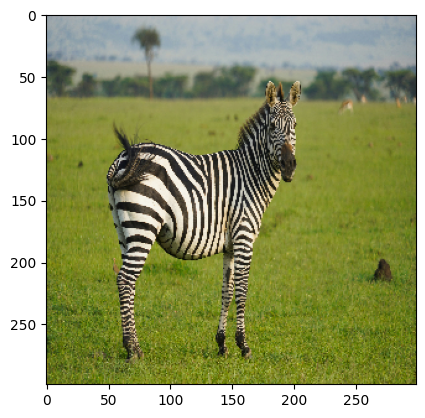

In [20]:
images = transform_img_fn([os.path.join('data','zebra.jpg')])

# Plotting the image
plt.imshow(images[0] / 2 + 0.5)
preds = inet_model.predict(images)
decode_predictions(preds)
for x in decode_predictions(preds)[0]:
    print(x)

In [21]:
print("Indices of the top5 labels:")
print(preds[0].argsort()[-5:][::-1])
for i in decode_predictions(preds, top=5)[0]:
    print(f'Label: {i[1]} | Value: {i[2]:.3f}')

Indices of the top5 labels:
[340   9 351 576 276]
Label: zebra | Value: 0.947
Label: ostrich | Value: 0.001
Label: hartebeest | Value: 0.001
Label: gondola | Value: 0.001
Label: hyena | Value: 0.000


In [22]:
%load_ext autoreload
%autoreload 2
import os,sys
try:
    import lime
except:
    sys.path.append(os.path.join('..', '..')) # add the current directory
    import lime
from lime import lime_image

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
# LIME explanation
explainer = lime_image.LimeImageExplainer()

In [24]:
%%time
# Hide color is the color for a superpixel turned OFF. Alternatively, if it is NONE, the superpixel will be replaced by the average of its pixels
explanation = explainer.explain_instance(images[0], inet_model.predict, top_labels=5, hide_color=0, num_samples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


  1%|          | 10/1000 [00:01<02:09,  7.66it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


  2%|▏         | 20/1000 [00:01<01:07, 14.53it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


 99%|█████████▉| 990/1000 [00:28<00:00, 33.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


100%|██████████| 1000/1000 [00:28<00:00, 35.35it/s]

CPU times: total: 3min 57s
Wall time: 28.9 s


Nb of superpixels:  63


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_11480\3362635463.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(skimage.segmentation.mark_boundaries(images[0]/2+0.5, explanation.segments))


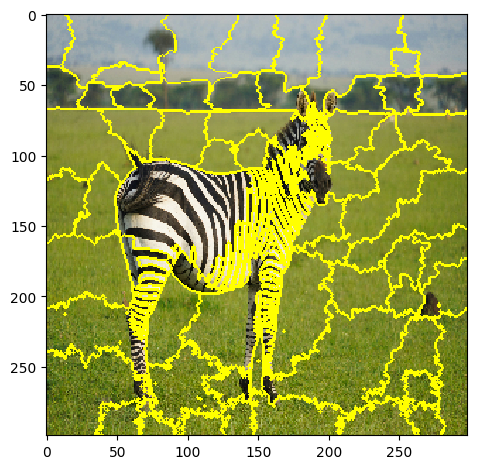

In [25]:
# All superpixels
skimage.io.imshow(skimage.segmentation.mark_boundaries(images[0]/2+0.5, explanation.segments))
print("Nb of superpixels: ",len(np.unique(explanation.segments)))

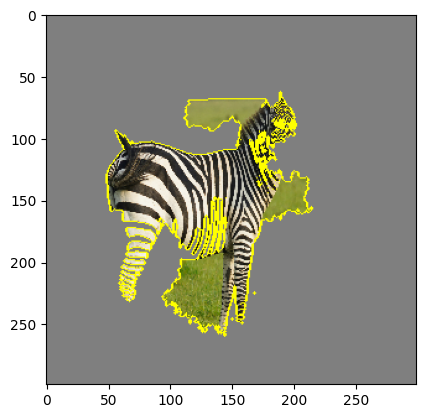

In [26]:
# Visualizing the explanation (i.e. the 5 most important superpixels supporting the top1 class)
top_label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(top_label, positive_only=True, num_features=5, hide_rest=True)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

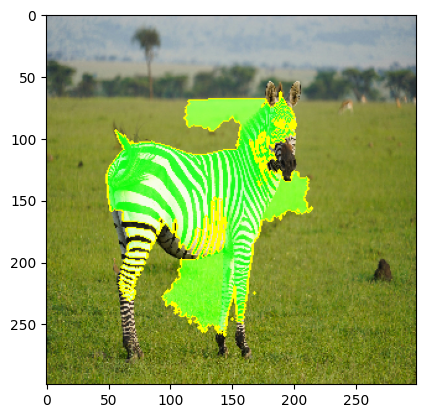

In [27]:
# Visualizing the 5 most important superpixels, either supporting the top1 class or not
temp, mask = explanation.get_image_and_mask(top_label, positive_only=False, num_features=5, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))